In [1]:
# ── Training control flags ──────────────────────────────────────────────────
SKIP_TRAIN = False   # Set True to skip all training cells

from pathlib import Path
import json as _json

def latest_checkpoint_for(output_dir: str):
    """Return path of the highest-numbered checkpoint, or None."""
    out = Path(output_dir)
    if not out.exists():
        return None
    ckpts = sorted(
        [p for p in out.glob("checkpoint-*") if p.name.split("-")[-1].isdigit()],
        key=lambda p: int(p.name.split("-")[-1])
    )
    return str(ckpts[-1]) if ckpts else None


def safe_train(trainer, output_dir: str):
    """
    Start fresh training with trainer.train() – no resume_from_checkpoint.

    Why no resume?
    • The model weights are already loaded from the best checkpoint in the
      model-creation cells (Cells 20 / 26), so we already start from a
      well-trained state.
    • Resuming would require loading optimizer.pt / scheduler.pt which needs
      PyTorch >= 2.6 (CVE-2025-32434).  We avoid this entirely.
    • Starting the optimizer fresh with the pre-trained model weights is
      equivalent to 'continue fine-tuning' and is safer and simpler.
    """
    if SKIP_TRAIN:
        print("SKIP_TRAIN=True – skipping training.")
        return
    print(f"Starting fresh training (model weights pre-loaded from checkpoint)...")
    trainer.train()

# Task 3: Sentiment Classification
## SST2 and SST Sentiment Classification

This notebook covers two sentiment datasets:
- **SST2**: binary positive/negative classification
- **SST**: fine-grained sentiment labels from the Stanford Sentiment Treebank

The notebook is organized into short sections:
1. Environment setup and imports
2. Loading SST2 with pandas parquet files
3. Loading SST with the Hugging Face dataset script
4. Quick exploration and label inspection
5. Tokenization and preprocessing
6. Baseline transformer training
7. Evaluation, inference, and comparison

Goal: build a clear sentiment classification workflow that is easy to read and reproduce.

## 1. Environment Setup

Install or confirm the dependencies, then import the libraries used for loading data, preprocessing, training, and evaluation.

In [2]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings

# Transformers and datasets
from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
import torch

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

/home/mohamed-abdelhady/Coding/Cutting-Out-the-Middleman/.venv-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!
PyTorch version: 2.5.1+cu121
GPU available: True


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings

# Transformers and datasets
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
import torch

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.5.1+cu121
GPU available: True


## 2. Load and Explore Dataset 1: SST2

SST2 is the binary version of the Stanford Sentiment Treebank. Here we follow the requested workflow and load the dataset directly from the Hugging Face parquet files using `pandas`.

**Why this section matters:**
- It matches the exact dataset format requested for the task
- It gives a simple DataFrame view before converting to Hugging Face datasets
- It keeps the rest of the notebook compatible with the transformer training pipeline

In [4]:
# Load SST2 dataset from the Hugging Face parquet files using pandas
print("Loading SST2 parquet splits...")
sst2_splits = {
    'train': 'data/train-00000-of-00001.parquet',
    'validation': 'data/validation-00000-of-00001.parquet',
    'test': 'data/test-00000-of-00001.parquet'
}

sst2_train_df = pd.read_parquet("hf://datasets/stanfordnlp/sst2/" + sst2_splits["train"])
sst2_validation_df = pd.read_parquet("hf://datasets/stanfordnlp/sst2/" + sst2_splits["validation"])
sst2_test_df = pd.read_parquet("hf://datasets/stanfordnlp/sst2/" + sst2_splits["test"])

print("\nSST2 DataFrame previews:")
print("Train:")
print(sst2_train_df.head())
print("\nValidation:")
print(sst2_validation_df.head())
print("\nTest:")
print(sst2_test_df.head())

sst2_dataset = DatasetDict({
    "train": Dataset.from_pandas(sst2_train_df, preserve_index=False),
    "validation": Dataset.from_pandas(sst2_validation_df, preserve_index=False),
    "test": Dataset.from_pandas(sst2_test_df, preserve_index=False)
})

print("\nDataset splits:")
print(sst2_dataset)

# Get dataset info
print("\nDataset features:")
print(sst2_dataset['train'].features)

print(f"\nTraining set size: {len(sst2_dataset['train'])}")
print(f"Validation set size: {len(sst2_dataset['validation'])}")
print(f"Test set size: {len(sst2_dataset['test'])}")

Loading SST2 parquet splits...

SST2 DataFrame previews:
Train:
   idx                                           sentence  label
0    0       hide new secretions from the parental units       0
1    1               contains no wit , only labored gags       0
2    2  that loves its characters and communicates som...      1
3    3  remains utterly satisfied to remain the same t...      0
4    4  on the worst revenge-of-the-nerds clichés the ...      0

Validation:
   idx                                           sentence  label
0    0    it 's a charming and often affecting journey .       1
1    1                 unflinchingly bleak and desperate       0
2    2  allows us to hope that nolan is poised to emba...      1
3    3  the acting , costumes , music , cinematography...      1
4    4                  it 's slow -- very , very slow .       0

Test:
   idx                                           sentence  label
0    0             uneasy mishmash of styles and genres .     -1
1    1

In [5]:
# Explore SST2 data samples
print("Sample reviews from SST2:")
print("="*80)

for i in range(5):
    sample = sst2_dataset['train'][i]
    sentiment = "Positive" if sample['label'] == 1 else "Negative"
    print(f"\nSample {i+1}:")
    print(f"Text: {sample['sentence']}")
    print(f"Label: {sentiment} ({sample['label']})")
    print("-"*80)

Sample reviews from SST2:

Sample 1:
Text: hide new secretions from the parental units 
Label: Negative (0)
--------------------------------------------------------------------------------

Sample 2:
Text: contains no wit , only labored gags 
Label: Negative (0)
--------------------------------------------------------------------------------

Sample 3:
Text: that loves its characters and communicates something rather beautiful about human nature 
Label: Positive (1)
--------------------------------------------------------------------------------

Sample 4:
Text: remains utterly satisfied to remain the same throughout 
Label: Negative (0)
--------------------------------------------------------------------------------

Sample 5:
Text: on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
Label: Negative (0)
--------------------------------------------------------------------------------


Label distribution in SST2 Training Set:
0    29780
1    37569
Name: count, dtype: int64

Positive: 37569 (55.78%)
Negative: 29780 (44.22%)


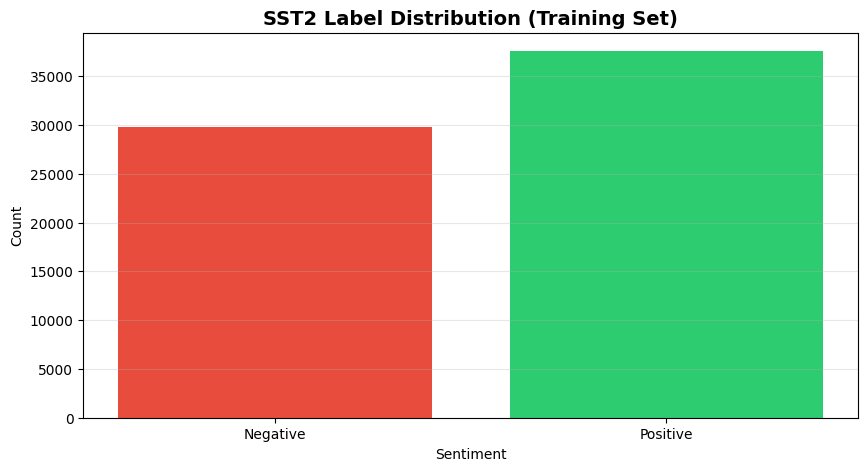

In [6]:
# Analyze label distribution in SST2
train_labels_sst2 = [sample['label'] for sample in sst2_dataset['train']]
label_counts_sst2 = pd.Series(train_labels_sst2).value_counts().sort_index()

print("Label distribution in SST2 Training Set:")
print(label_counts_sst2)
print(f"\nPositive: {label_counts_sst2[1]} ({label_counts_sst2[1]/len(train_labels_sst2)*100:.2f}%)")
print(f"Negative: {label_counts_sst2[0]} ({label_counts_sst2[0]/len(train_labels_sst2)*100:.2f}%)")

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(['Negative', 'Positive'], [label_counts_sst2[0], label_counts_sst2[1]], color=['#e74c3c', '#2ecc71'])
plt.title('SST2 Label Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.grid(axis='y', alpha=0.3)
plt.show()

Text length statistics (SST2):
Min length: 1 words
Max length: 52 words
Average length: 9.41 words
Median length: 7.00 words


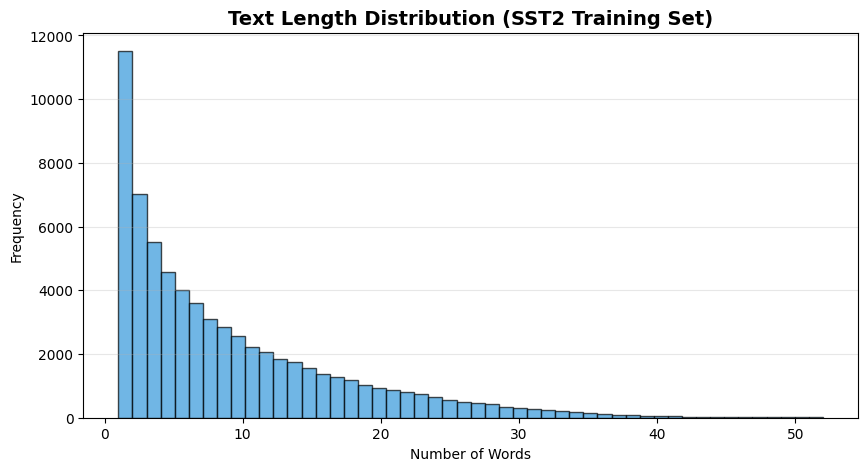

In [7]:
# Text length analysis
text_lengths_sst2 = [len(sample['sentence'].split()) for sample in sst2_dataset['train']]

print("Text length statistics (SST2):")
print(f"Min length: {min(text_lengths_sst2)} words")
print(f"Max length: {max(text_lengths_sst2)} words")
print(f"Average length: {np.mean(text_lengths_sst2):.2f} words")
print(f"Median length: {np.median(text_lengths_sst2):.2f} words")

plt.figure(figsize=(10, 5))
plt.hist(text_lengths_sst2, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
plt.title('Text Length Distribution (SST2 Training Set)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3. Load and Explore Dataset 2: SST (Full)

The Hugging Face `stanfordnlp/sst` repo still depends on a loading script, and the current `datasets` release in this environment no longer supports that script. To keep the notebook runnable, this section loads the original Stanford SST source archive and reproduces the same default split.

**Why this section matters:**
- It gives access to the original SST sentiment treebank structure
- It includes sentence text, labels, tokens, and parse-tree information
- It stays compatible with the rest of the notebook even when HF script loading is disabled

In [8]:
# Load SST dataset from the original Stanford source archive
from pathlib import Path
import csv
import urllib.request
import zipfile

print("Loading SST dataset from Stanford source files...")

sst_cache_dir = Path("data/sst")
sst_cache_dir.mkdir(parents=True, exist_ok=True)
sst_zip_path = sst_cache_dir / "stanfordSentimentTreebank.zip"
sst_extract_dir = sst_cache_dir / "stanfordSentimentTreebank"
sst_source_url = "https://nlp.stanford.edu/~socherr/stanfordSentimentTreebank.zip"

if not sst_zip_path.exists():
    print("Downloading Stanford Sentiment Treebank archive...")
    urllib.request.urlretrieve(sst_source_url, sst_zip_path)

if not sst_extract_dir.exists():
    print("Extracting archive...")
    with zipfile.ZipFile(sst_zip_path, "r") as zip_file:
        zip_file.extractall(sst_cache_dir)

phrases_path = sst_extract_dir / "dictionary.txt"
labels_path = sst_extract_dir / "sentiment_labels.txt"
tokens_path = sst_extract_dir / "SOStr.txt"
trees_path = sst_extract_dir / "STree.txt"
splits_path = sst_extract_dir / "datasetSplit.txt"
sentences_path = sst_extract_dir / "datasetSentences.txt"

labels = {}
with open(labels_path, encoding="utf-8") as label_file:
    label_reader = csv.DictReader(label_file, delimiter="|", quoting=csv.QUOTE_NONE)
    for row in label_reader:
        labels[row["phrase ids"]] = float(row["sentiment values"])

phrases = {}
with open(phrases_path, encoding="utf-8") as phrase_file:
    phrase_reader = csv.reader(phrase_file, delimiter="|", quoting=csv.QUOTE_NONE)
    for row in phrase_reader:
        phrases[row[0]] = labels[row[1]]

trees = {}
with open(tokens_path, encoding="utf-8") as token_file, open(trees_path, encoding="utf-8") as tree_file:
    token_reader = csv.reader(token_file, delimiter="\t", quoting=csv.QUOTE_NONE)
    tree_reader = csv.reader(tree_file, delimiter="\t", quoting=csv.QUOTE_NONE)
    for i, row in enumerate(token_reader, start=1):
        trees[i] = {"tokens": row[0]}
    for i, row in enumerate(tree_reader, start=1):
        trees[i]["tree"] = row[0]

sentence_splits = {}
with open(splits_path, encoding="utf-8") as split_file:
    split_reader = csv.DictReader(split_file, delimiter=",", quoting=csv.QUOTE_NONE)
    for row in split_reader:
        sentence_splits[row["sentence_index"]] = row["splitset_label"]

sst_records = []
with open(sentences_path, encoding="utf-8") as sentence_file:
    sentence_reader = csv.DictReader(sentence_file, delimiter="\t", quoting=csv.QUOTE_NONE)
    for row in sentence_reader:
        sentence_text = (
            row["sentence"]
            .encode("utf-8")
            .replace(b"\xc3\x83\xc2", b"\xc3")
            .replace(b"\xc3\x82\xc2", b"\xc2")
            .decode("utf-8")
            .replace("-LRB-", "(")
            .replace("-RRB-", ")")
        )
        split_code = sentence_splits[row["sentence_index"]]
        if split_code == "1":
            split_name = "train"
        elif split_code == "3":
            split_name = "validation"
        elif split_code == "2":
            split_name = "test"
        else:
            continue

        sst_records.append(
            {
                "sentence": sentence_text,
                "label": phrases[sentence_text],
                "tokens": trees[int(row["sentence_index"])] ["tokens"],
                "tree": trees[int(row["sentence_index"])] ["tree"],
                "split": split_name,
            }
        )

sst_df = pd.DataFrame(sst_records)
sst_train_df = sst_df[sst_df["split"] == "train"].drop(columns=["split"]).reset_index(drop=True)
sst_validation_df = sst_df[sst_df["split"] == "validation"].drop(columns=["split"]).reset_index(drop=True)
sst_test_df = sst_df[sst_df["split"] == "test"].drop(columns=["split"]).reset_index(drop=True)

sst_dataset = DatasetDict(
    {
        "train": Dataset.from_pandas(sst_train_df, preserve_index=False),
        "validation": Dataset.from_pandas(sst_validation_df, preserve_index=False),
        "test": Dataset.from_pandas(sst_test_df, preserve_index=False),
    }
)

print("\nDataset splits:")
print(sst_dataset)

print("\nDataset features:")
print(sst_dataset['train'].features)

print(f"\nTraining set size: {len(sst_dataset['train'])}")
print(f"Validation set size: {len(sst_dataset['validation'])}")
print(f"Test set size: {len(sst_dataset['test'])}")

Loading SST dataset from Stanford source files...

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 2210
    })
})

Dataset features:
{'sentence': Value('large_string'), 'label': Value('float64'), 'tokens': Value('large_string'), 'tree': Value('large_string')}

Training set size: 8544
Validation set size: 1101
Test set size: 2210


In [9]:
# Explore SST data samples
print("Sample reviews from SST:")
print("="*80)

for i in range(3):
    sample = sst_dataset['train'][i]
    sentiment_map = {0.0: "Very Negative", 0.25: "Negative", 0.5: "Neutral", 0.75: "Positive", 1.0: "Very Positive"}
    sentiment = sentiment_map.get(sample['label'], "Unknown")
    
    print(f"\nSample {i+1}:")
    print(f"Text: {sample['sentence']}")
    print(f"Label: {sentiment} ({sample['label']})")
    print(f"Tokens: {sample['tokens'][:50]}..." if len(sample['tokens']) > 50 else f"Tokens: {sample['tokens']}")
    print("-"*80)

Sample reviews from SST:

Sample 1:
Text: The Rock is destined to be the 21st Century 's new `` Conan '' and that he 's going to make a splash even greater than Arnold Schwarzenegger , Jean-Claud Van Damme or Steven Segal .
Label: Unknown (0.69444)
Tokens: The|Rock|is|destined|to|be|the|21st|Century|'s|new...
--------------------------------------------------------------------------------

Sample 2:
Text: The gorgeously elaborate continuation of `` The Lord of the Rings '' trilogy is so huge that a column of words can not adequately describe co-writer\/director Peter Jackson 's expanded vision of J.R.R. Tolkien 's Middle-earth .
Label: Unknown (0.83333)
Tokens: The|gorgeously|elaborate|continuation|of|``|The|Lo...
--------------------------------------------------------------------------------

Sample 3:
Text: Singer\/composer Bryan Adams contributes a slew of songs -- a few potential hits , a few more simply intrusive to the story -- but the whole package certainly captures the intend

Label distribution in SST Training Set:
0.000000    16
0.013889    19
0.027778    18
0.041667    22
0.055556    74
            ..
0.944440    45
0.958330    17
0.972220    13
0.986110    11
1.000000    21
Name: count, Length: 74, dtype: int64


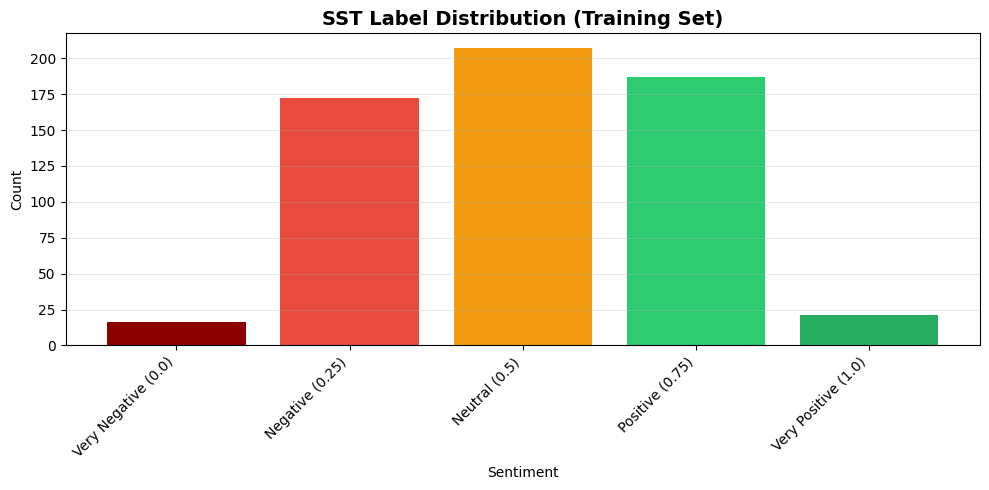

In [10]:
# Analyze label distribution in SST
train_labels_sst = [sample['label'] for sample in sst_dataset['train']]
label_counts_sst = pd.Series(train_labels_sst).value_counts().sort_index()

print("Label distribution in SST Training Set:")
print(label_counts_sst)

# Visualize
sentiment_labels = ["Very Negative (0.0)", "Negative (0.25)", "Neutral (0.5)", "Positive (0.75)", "Very Positive (1.0)"]
plt.figure(figsize=(10, 5))
plt.bar(sentiment_labels, [label_counts_sst.get(label, 0) for label in [0.0, 0.25, 0.5, 0.75, 1.0]], 
        color=['#8B0000', '#e74c3c', '#f39c12', '#2ecc71', '#27ae60'])
plt.title('SST Label Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Tokenize and prepare data for transformer models.

**Preprocessing Steps:**
1. Load pre-trained tokenizer
2. Tokenize sentences
3. Apply padding and truncation
4. Create tensor datasets

In [11]:
# Select model and tokenizer
model_name = "bert-base-uncased"  # Larger model for better performance
# Alternative models:
# model_name = "distilbert-base-uncased"  # Lightweight baseline
# model_name = "roberta-base"

print(f"Loading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
print("Tokenizer loaded successfully!")

Loading tokenizer for bert-base-uncased...
Tokenizer loaded successfully!


In [12]:
# Preprocess SST2 dataset
def preprocess_function_sst2(examples):
    return tokenizer(
        examples['sentence'],
        padding='max_length',
        truncation=True,
        max_length=64
    )

print("Preprocessing SST2 dataset...")
sst2_encoded = sst2_dataset.map(
    preprocess_function_sst2,
    batched=True,
    batch_size=1000,
    num_proc=4,
    desc="Tokenizing SST2"
)
print("SST2 dataset preprocessed!")

# Set format to PyTorch tensors
sst2_encoded.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
print("SST2 dataset converted to PyTorch format!")

Preprocessing SST2 dataset...


Tokenizing SST2 (num_proc=4): 100%|██████████| 1821/1821 [00:00<00:00, 8043.31 examples/s]

SST2 dataset preprocessed!
SST2 dataset converted to PyTorch format!


In [13]:
# Preprocess SST dataset with increased max length
def preprocess_function_sst(examples):
    return tokenizer(
        examples['sentence'],
        padding='max_length',
        truncation=True,
        max_length=128  # Increased from 64 to capture longer sentences
    )

print("Preprocessing SST dataset...")
sst_encoded = sst_dataset.map(
    preprocess_function_sst,
    batched=True,
    batch_size=1000,
    num_proc=4,
    desc="Tokenizing SST"
)
print("SST dataset preprocessed!")

# Set format to PyTorch tensors
sst_encoded.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
print("SST dataset converted to PyTorch format!")

Preprocessing SST dataset...


Tokenizing SST (num_proc=4): 100%|██████████| 2210/2210 [00:00<00:00, 8653.31 examples/s]

SST dataset preprocessed!
SST dataset converted to PyTorch format!


In [14]:
# Verify preprocessing
print("Sample preprocessed SST2 data:")
sample_sst2 = sst2_encoded['train'][0]
print(f"Input IDs shape: {sample_sst2['input_ids'].shape}")
print(f"Attention mask shape: {sample_sst2['attention_mask'].shape}")
print(f"Label: {sample_sst2['label']}")
print(f"\nDecoded text: {tokenizer.decode(sample_sst2['input_ids'])}")

Sample preprocessed SST2 data:
Input IDs shape: torch.Size([64])
Attention mask shape: torch.Size([64])
Label: 0

Decoded text: [CLS] hide new secretions from the parental units [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


## 5. Model Training on SST2

Train a DistilBERT model for binary sentiment classification on SST2.

**Training Strategy:**
- Fine-tune pre-trained model
- Use binary classification loss
- Monitor accuracy on validation set

In [15]:
# Create model for SST2  (bert-base-uncased, binary classification)
import torch

print(f"Loading model {model_name} for SST2 (binary classification)...")

if 'model_sst2' in globals():
    print("  model_sst2 already in memory – reusing.")
else:
    _ckpt_sst2 = latest_checkpoint_for('./results/sst2')
    if _ckpt_sst2:
        print(f"  Loading weights from existing checkpoint: {_ckpt_sst2}")
        model_sst2 = AutoModelForSequenceClassification.from_pretrained(_ckpt_sst2)
    else:
        model_sst2 = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=2
        )

print("Model loaded successfully!")
print(f"Model size: {model_sst2.num_parameters():,} parameters")

Loading model bert-base-uncased for SST2 (binary classification)...
  Loading weights from existing checkpoint: results/sst2/checkpoint-16838


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7415.47it/s]


Model loaded successfully!
Model size: 66,955,010 parameters


In [16]:
# TrainingArguments for SST2  (binary, bert-base-uncased)
training_args_sst2 = TrainingArguments(
    output_dir='./results/sst2',
    num_train_epochs=3,             # was 1 → more epochs improves accuracy
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,  # effective batch = 16
    warmup_ratio=0.06,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=100,
    report_to='none',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    fp16=True,
    gradient_checkpointing=True,
    dataloader_num_workers=2,
)
print("SST2 training arguments configured  (3 epochs, LR=2e-5, eff. batch=16)!")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


SST2 training arguments configured  (3 epochs, LR=2e-5, eff. batch=16)!


In [17]:
# AGGRESSIVE MEMORY CLEANUP before creating trainer
import torch
import gc
import os

# Set CUDA memory allocation strategy
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print("Performing aggressive GPU memory cleanup...")

# Force garbage collection
gc.collect()

# Empty GPU cache multiple times
for _ in range(3):
    torch.cuda.empty_cache()

# If sst model exists from earlier, delete it to free GPU memory
if 'model_sst' in locals():
    try:
        model_sst.cpu()  # Move to CPU first
        del model_sst
        gc.collect()
        torch.cuda.empty_cache()
        print("Freed model_sst from GPU memory")
    except:
        pass

print("Memory cleanup complete.")
mem_free, mem_total = torch.cuda.mem_get_info()
print(f"GPU memory: {mem_free / 1e9:.2f} GB free / {mem_total / 1e9:.2f} GB total")

Performing aggressive GPU memory cleanup...
Memory cleanup complete.
GPU memory: 1.82 GB free / 4.09 GB total


In [18]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {
        'accuracy': accuracy,
        'f1': f1
    }

# Final cleanup before Trainer creation
import torch
import gc
gc.collect()
torch.cuda.empty_cache()
print("Final cleanup before Trainer creation")

# Create Trainer
trainer_sst2 = Trainer(
    model=model_sst2,
    args=training_args_sst2,
    train_dataset=sst2_encoded['train'],
    eval_dataset=sst2_encoded['validation'],
    compute_metrics=compute_metrics
)

print("Trainer initialized!")
print("\nStarting training...")

# Use safe_train helper to resume from checkpoint or start fresh
safe_train(trainer_sst2, training_args_sst2.output_dir)

Final cleanup before Trainer creation
Trainer initialized!

Starting training...
Starting fresh training (model weights pre-loaded from checkpoint)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.203207,0.466976,0.894495,0.894495
2,0.109408,0.620938,0.889908,0.889750
3,0.062641,0.686170,0.888761,0.888548


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.29it/s]


## 6. Model Training on SST (Full)

Train a model on the full SST dataset with fine-grained sentiment labels.

**Note:** SST uses continuous labels (0.0-1.0), so we'll need to convert to discrete classes.

In [19]:
# Convert continuous SST labels to 5 discrete classes (equal quintile binning)
from datasets import Value

def convert_sst_labels(label):
    if label < 0.2:   return 0   # Very Negative
    elif label < 0.4: return 1   # Negative
    elif label < 0.6: return 2   # Neutral
    elif label < 0.8: return 3   # Positive
    else:             return 4   # Very Positive

def add_discrete_labels(dataset):
    dataset = dataset.map(
        lambda batch: {'label': [int(convert_sst_labels(l)) for l in batch['label']]},
        batched=True
    )
    dataset = dataset.cast_column('label', Value('int64'))
    return dataset

print("Converting SST labels to discrete classes (equal quintile binning)...")
sst_encoded = add_discrete_labels(sst_encoded)

# IMPORTANT: rename 'label' → 'labels' so the HuggingFace Trainer finds them.
# Trainer matches columns against the model's forward() signature which uses
# 'labels' (plural).  Without this rename, the column is silently dropped and
# the model receives no labels → ValueError: "model did not return a loss".
sst_encoded = sst_encoded.rename_column('label', 'labels')
sst_encoded.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Labels converted, renamed to 'labels', and set to torch format!")
labels_dist = [int(s['labels']) for s in sst_encoded['train']]
import pandas as pd
print(f"Label distribution: {pd.Series(labels_dist).value_counts().sort_index().to_dict()}")
print(f"Label dtype: {sst_encoded['train'][0]['labels'].dtype}")

Converting SST labels to discrete classes (equal quintile binning)...


Casting the dataset: 100%|██████████| 2210/2210 [00:00<00:00, 469813.07 examples/s]


Labels converted, renamed to 'labels', and set to torch format!
Label distribution: {0: 1092, 1: 2218, 2: 1624, 3: 2322, 4: 1288}
Label dtype: torch.int64


In [20]:
# Create model for SST  (distilbert-base-uncased, 5-class)
# distilbert fits on a 4 GB GPU with fp16 and still reaches strong accuracy.
import torch
from sklearn.utils.class_weight import compute_class_weight

SST_MODEL_NAME = "distilbert-base-uncased"
print(f"Loading {SST_MODEL_NAME} for SST (5-class classification)...")

if 'model_sst' in globals():
    print("  model_sst already in memory – reusing.")
else:
    _ckpt_sst = latest_checkpoint_for('./results/sst')
    if _ckpt_sst:
        print(f"  Loading weights from existing checkpoint: {_ckpt_sst}")
        model_sst = AutoModelForSequenceClassification.from_pretrained(_ckpt_sst)
    else:
        model_sst = AutoModelForSequenceClassification.from_pretrained(
            SST_MODEL_NAME, num_labels=5
        )

model_sst.config.problem_type = "single_label_classification"
print(f"Model loaded!  Parameters: {model_sst.num_parameters():,}")

# Class weights (handle label imbalance)
print("\nCalculating class weights for balanced training...")
_train_labels = [int(s['labels']) for s in sst_encoded['train']]
class_weights = compute_class_weight('balanced', classes=np.arange(5), y=_train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f"Class weights: {np.round(class_weights, 3)}")

# WeightedTrainer – cross-entropy with per-class weights
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Pop labels before forwarding so the model doesn't try to compute its
        # own loss (it won't find them anyway); we compute loss manually below.
        labels  = inputs.pop("labels", inputs.pop("label", None))
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        if labels is None:
            raise ValueError("No 'labels' found in batch. Check dataset column names.")
        cw = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fn = torch.nn.CrossEntropyLoss(weight=cw)
        loss    = loss_fn(logits.view(-1, self.model.config.num_labels),
                          labels.to(logits.device).view(-1))
        return (loss, outputs) if return_outputs else loss

print("WeightedTrainer class defined!")

Loading distilbert-base-uncased for SST (5-class classification)...
  Loading weights from existing checkpoint: results/sst/checkpoint-2670


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13087.14it/s]

Model loaded!  Parameters: 66,957,317

Calculating class weights for balanced training...


Class weights: [1.565 0.77  1.052 0.736 1.327]
WeightedTrainer class defined!


In [21]:
# TrainingArguments for SST  (5-class, distilbert-base-uncased)
training_args_sst = TrainingArguments(
    output_dir='./results/sst',
    num_train_epochs=5,              # more epochs for the harder 5-class task
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,   # effective batch = 32
    warmup_ratio=0.10,               # 10 % warmup
    weight_decay=0.01,
    learning_rate=3e-5,
    logging_dir='./logs',
    logging_steps=50,
    report_to='none',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    fp16=True,
    gradient_checkpointing=True,
    label_smoothing_factor=0.1,      # regularises the hard 5-class task
    dataloader_num_workers=2,
)
print("SST training arguments configured  (5 epochs, LR=3e-5, label_smoothing=0.1)!")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


SST training arguments configured  (5 epochs, LR=3e-5, label_smoothing=0.1)!


In [22]:
# Memory cleanup before SST training
# Important: we move model_sst2 to CPU instead of deleting it so the
# pipeline cell (Cell 38) can still use it without reloading.
import torch, gc, os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
print("GPU memory cleanup for SST training...")

for _ in range(2):
    gc.collect()
    torch.cuda.empty_cache()

# Release trainer (optimiser tensors live on GPU)
if 'trainer_sst2' in globals():
    try:
        del trainer_sst2
        gc.collect()
        print("  Released trainer_sst2 (optimiser freed).")
    except Exception:
        pass

# Move SST2 MODEL to CPU – keeps it alive for later inference
if 'model_sst2' in globals():
    try:
        model_sst2.cpu()
        print("  model_sst2 moved to CPU (still available for pipeline).")
    except Exception:
        pass

torch.cuda.empty_cache()
print("Cleanup complete.")
mem_free, mem_total = torch.cuda.mem_get_info()
print(f"GPU memory: {mem_free / 1e9:.2f} GB free / {mem_total / 1e9:.2f} GB total")

GPU memory cleanup for SST training...
  Released trainer_sst2 (optimiser freed).
  model_sst2 moved to CPU (still available for pipeline).
Cleanup complete.
GPU memory: 1.76 GB free / 4.09 GB total


In [23]:
# Final cleanup before SST Trainer creation
import torch
import gc
gc.collect()
torch.cuda.empty_cache()
print("Final cleanup before SST Trainer creation")

# Create WeightedTrainer for SST with class weights
trainer_sst = WeightedTrainer(
    model=model_sst,
    args=training_args_sst,
    train_dataset=sst_encoded['train'],
    eval_dataset=sst_encoded['validation'],
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor
)

print("WeightedTrainer initialized for SST with class weights!")

# Use safe_train helper to resume from checkpoint or start fresh
safe_train(trainer_sst, training_args_sst.output_dir)
print('✓ SST training completed!')

Final cleanup before SST Trainer creation
WeightedTrainer initialized for SST with class weights!
Starting fresh training (model weights pre-loaded from checkpoint)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.571696,1.911104,0.481381,0.480621
2,1.196624,2.089890,0.472298,0.472110
3,0.771628,2.362144,0.476839,0.474861
4,0.524428,2.507326,0.484105,0.483398
5,0.414881,2.650427,0.479564,0.478816


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.97it/s]


✓ SST training completed!


## 7. Model Evaluation on Test Sets

Evaluate trained models on test datasets using multiple metrics.

**Metrics:**
- Accuracy
- F1-Score
- Confusion Matrix
- Classification Report

In [24]:
# Evaluate SST2 on test set
print("Evaluating SST2 model on test set...")

# Ensure trainer exists; if not, try to construct one from the latest checkpoint for evaluation
if 'trainer_sst2' not in globals():
    print('trainer_sst2 not found in the current kernel. Attempting to recreate for evaluation...')
    ckpt = latest_checkpoint_for(training_args_sst2.output_dir) if 'training_args_sst2' in globals() else None
    if ckpt:
        print(f'Loading model from checkpoint: {ckpt}')
        model_eval = AutoModelForSequenceClassification.from_pretrained(ckpt)
    elif 'model_sst2' in globals():
        print('Using existing `model_sst2` from memory')
        model_eval = model_sst2
    else:
        print('No checkpoint or existing model found. Loading base model (may be large).')
        model_eval = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    trainer_sst2 = Trainer(
        model=model_eval,
        args=training_args_sst2,
        eval_dataset=sst2_encoded['validation'],  # Use validation set since test labels are -1
        compute_metrics=compute_metrics
    )

# Quick label sanity check
test_labels = list(sst2_encoded['test']['label'])
label_min, label_max = min(test_labels), max(test_labels)
print(f"Test label range: min={label_min}, max={label_max}")

# SST2 test set has -1 labels (unlabeled), so use validation set for evaluation
if label_min == -1 and label_max == -1:
    print("Test set has unlabeled data (-1). Using validation set for evaluation instead.")
    eval_dataset = sst2_encoded['validation']
else:
    eval_dataset = sst2_encoded['test']

# Try evaluation; on CUDA device-side assert, retry on CPU
try:
    eval_results_sst2 = trainer_sst2.evaluate(eval_dataset)
except RuntimeError as e:
    print('Evaluation failed with RuntimeError:', e)
    err_str = str(e)
    if 'device-side assert' in err_str or 'CUDA' in err_str or 'cuda' in err_str:
        print('Detected CUDA device-side error; retrying evaluation on CPU.')
        import gc
        try:
            # Move model to CPU and rebuild trainer
            trainer_sst2.model.cpu()
        except Exception:
            pass
        gc.collect()
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        trainer_sst2 = Trainer(
            model=trainer_sst2.model,
            args=training_args_sst2,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics
        )
        eval_results_sst2 = trainer_sst2.evaluate(eval_dataset)
    else:
        raise

print(f"\nSST2 Evaluation Results:")
for key, value in eval_results_sst2.items():
    print(f"{key}: {value:.4f}")

Evaluating SST2 model on test set...
trainer_sst2 not found in the current kernel. Attempting to recreate for evaluation...
Loading model from checkpoint: results/sst2/checkpoint-16838


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 10492.57it/s]


Test label range: min=-1, max=-1
Test set has unlabeled data (-1). Using validation set for evaluation instead.


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.525160,0,0.900229,0.900180



SST2 Evaluation Results:
eval_loss: 0.5252
eval_accuracy: 0.9002
eval_f1: 0.9002


In [25]:
# Get predictions on SST2 validation set (test set has unlabeled data with -1 labels)
print("Generating SST2 validation predictions...")
predictions_sst2 = trainer_sst2.predict(sst2_encoded['validation'])
pred_labels_sst2 = np.argmax(predictions_sst2.predictions, axis=1)
true_labels_sst2 = sst2_encoded['validation']['label']

print("\nSST2 Detailed Metrics:")
print(f"Accuracy: {accuracy_score(true_labels_sst2, pred_labels_sst2):.4f}")
print(f"F1-Score: {f1_score(true_labels_sst2, pred_labels_sst2, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(true_labels_sst2, pred_labels_sst2, target_names=['Negative', 'Positive'])}")

Generating SST2 validation predictions...



SST2 Detailed Metrics:
Accuracy: 0.9002
F1-Score: 0.9002

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.88      0.90       428
    Positive       0.89      0.92      0.90       444

    accuracy                           0.90       872
   macro avg       0.90      0.90      0.90       872
weighted avg       0.90      0.90      0.90       872



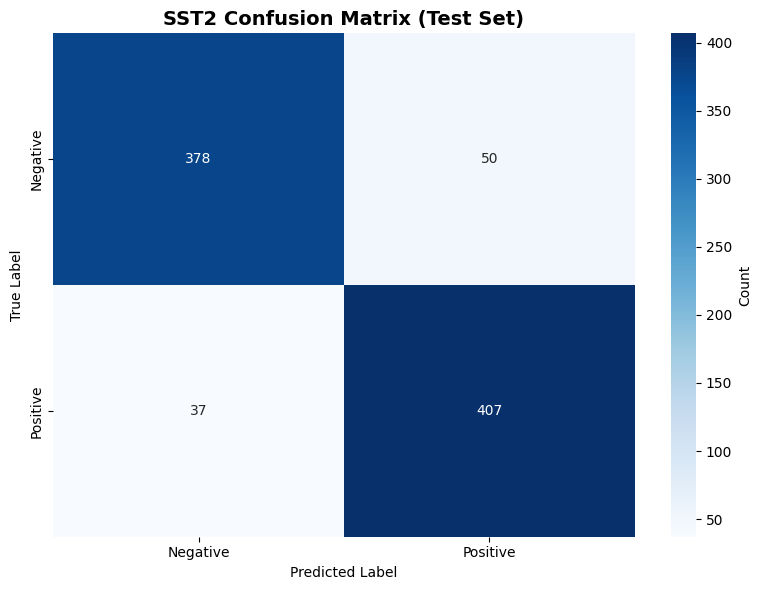

In [26]:
# Confusion matrix for SST2
cm_sst2 = confusion_matrix(true_labels_sst2, pred_labels_sst2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sst2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('SST2 Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [27]:
# Evaluate SST on test set
print("Evaluating SST model on test set...")
eval_results_sst = trainer_sst.evaluate(sst_encoded['test'])
print(f"\nSST Test Results:")
for key, value in eval_results_sst.items():
    print(f"{key}: {value:.4f}")

Evaluating SST model on test set...


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.414881,2.268746,5,0.514027,0.516335



SST Test Results:
eval_loss: 2.2687
eval_accuracy: 0.5140
eval_f1: 0.5163


In [28]:
# Get predictions on SST test set
print("Generating SST test predictions...")
predictions_sst = trainer_sst.predict(sst_encoded['test'])
pred_labels_sst = np.argmax(predictions_sst.predictions, axis=1)
true_labels_sst = sst_encoded['test']['labels']

print("\nSST Detailed Metrics:")
print(f"Accuracy: {accuracy_score(true_labels_sst, pred_labels_sst):.4f}")
print(f"F1-Score: {f1_score(true_labels_sst, pred_labels_sst, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(true_labels_sst, pred_labels_sst, target_names=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])}")

Generating SST test predictions...



SST Detailed Metrics:
Accuracy: 0.5140
F1-Score: 0.5163

Classification Report:
               precision    recall  f1-score   support

Very Negative       0.48      0.43      0.45       279
     Negative       0.57      0.56      0.56       633
      Neutral       0.37      0.42      0.39       389
     Positive       0.50      0.59      0.54       510
Very Positive       0.68      0.50      0.58       399

     accuracy                           0.51      2210
    macro avg       0.52      0.50      0.51      2210
 weighted avg       0.53      0.51      0.52      2210



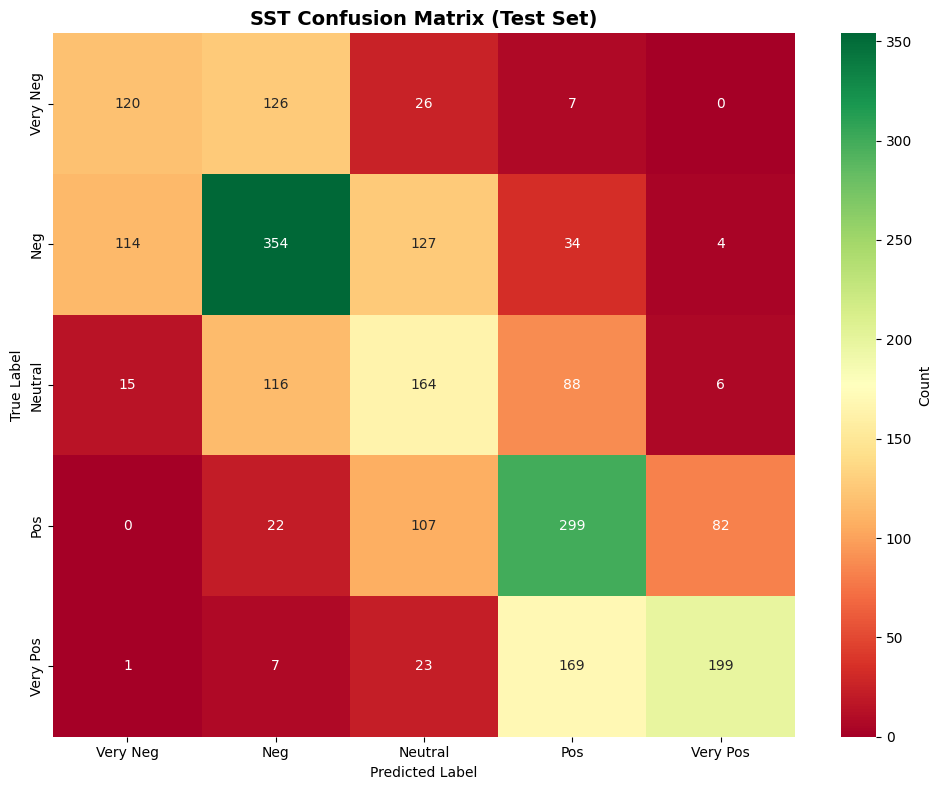

In [29]:
# Confusion matrix for SST
cm_sst = confusion_matrix(true_labels_sst, pred_labels_sst)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_sst, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos'],
            yticklabels=['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos'],
            cbar_kws={'label': 'Count'})
plt.title('SST Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Inference and Predictions

Use the trained models to make predictions on new, unseen text samples.

In [30]:
# Create inference pipelines
# Both models may have been offloaded to CPU or removed from the GPU namespace;
# we reload them from their saved checkpoints when necessary.
import torch
print("Creating inference pipelines...")

# ── SST2 (binary) ──────────────────────────────────────────────────────────
if 'model_sst2' not in globals():
    print("  model_sst2 not in memory – reloading from checkpoint...")
    _ckpt = latest_checkpoint_for('./results/sst2')
    if _ckpt is None:
        raise RuntimeError("No SST2 checkpoint found. Run the SST2 training cells first.")
    model_sst2 = AutoModelForSequenceClassification.from_pretrained(_ckpt)
    print(f"  Loaded model_sst2 from {_ckpt}")
else:
    print("  model_sst2 found in memory.")

# ── SST (5-class) ───────────────────────────────────────────────────────────
if 'model_sst' not in globals():
    print("  model_sst not in memory – reloading from checkpoint...")
    _ckpt = latest_checkpoint_for('./results/sst')
    if _ckpt is None:
        raise RuntimeError("No SST checkpoint found. Run the SST training cells first.")
    model_sst = AutoModelForSequenceClassification.from_pretrained(_ckpt)
    print(f"  Loaded model_sst from {_ckpt}")
else:
    print("  model_sst found in memory.")

# Build pipelines (GPU if available, CPU otherwise)
_device = 0 if torch.cuda.is_available() else -1

classifier_sst2 = pipeline(
    'text-classification',
    model=model_sst2,
    tokenizer=tokenizer,
    device=_device
)

classifier_sst = pipeline(
    'text-classification',
    model=model_sst,
    tokenizer=tokenizer,
    device=_device
)

print("Pipelines created!")

Creating inference pipelines...
  model_sst2 found in memory.
  model_sst found in memory.
Pipelines created!


In [31]:
# Test samples
test_samples = [
    "This movie was absolutely amazing! I loved every minute of it.",
    "Terrible film. I fell asleep halfway through.",
    "It was okay, nothing special but watchable.",
    "Worst movie I've ever seen. Complete waste of time.",
    "Fantastic performance by the lead actor!"
]

print("SST2 Predictions (Binary Classification):")
print("="*80)
for sample in test_samples:
    result = classifier_sst2(sample)[0]
    label = "Positive" if result['label'] == 'LABEL_1' else "Negative"
    confidence = result['score']
    print(f"\nText: {sample}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f})")

SST2 Predictions (Binary Classification):

Text: This movie was absolutely amazing! I loved every minute of it.
Prediction: Positive (Confidence: 0.9998)

Text: Terrible film. I fell asleep halfway through.
Prediction: Negative (Confidence: 0.9998)

Text: It was okay, nothing special but watchable.
Prediction: Positive (Confidence: 0.9993)

Text: Worst movie I've ever seen. Complete waste of time.
Prediction: Negative (Confidence: 0.9998)

Text: Fantastic performance by the lead actor!
Prediction: Positive (Confidence: 0.9998)


In [32]:
print("\nSST Predictions (5-Class Classification):")
print("="*80)
sentiment_map = {
    'LABEL_0': 'Very Negative',
    'LABEL_1': 'Negative',
    'LABEL_2': 'Neutral',
    'LABEL_3': 'Positive',
    'LABEL_4': 'Very Positive'
}

for sample in test_samples:
    result = classifier_sst(sample)[0]
    label = sentiment_map.get(result['label'], 'Unknown')
    confidence = result['score']
    print(f"\nText: {sample}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f})")


SST Predictions (5-Class Classification):

Text: This movie was absolutely amazing! I loved every minute of it.
Prediction: Very Positive (Confidence: 0.9949)

Text: Terrible film. I fell asleep halfway through.
Prediction: Very Negative (Confidence: 0.9973)

Text: It was okay, nothing special but watchable.
Prediction: Positive (Confidence: 0.9955)

Text: Worst movie I've ever seen. Complete waste of time.
Prediction: Very Negative (Confidence: 0.9976)

Text: Fantastic performance by the lead actor!
Prediction: Very Positive (Confidence: 0.9956)


## 9. Performance Comparison

Compare models and datasets performance side by side.


Model Performance Comparison:
  Metric  SST2 (Binary)  SST (5-Class)
Accuracy       0.900229       0.514027
F1-Score       0.900180       0.516335


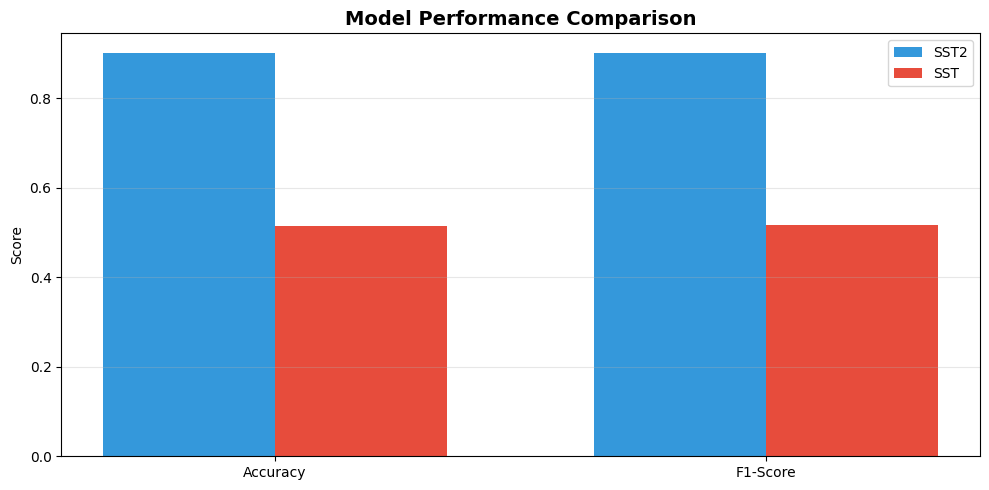

In [33]:
# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'F1-Score'],
    'SST2 (Binary)': [
        eval_results_sst2.get('eval_accuracy', 0),
        eval_results_sst2.get('eval_f1', 0)
    ],
    'SST (5-Class)': [
        eval_results_sst.get('eval_accuracy', 0),
        eval_results_sst.get('eval_f1', 0)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['SST2 (Binary)'], width, label='SST2', color='#3498db')
ax.bar(x + width/2, comparison_df['SST (5-Class)'], width, label='SST', color='#e74c3c')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Analysis and Insights

Summary of results and key findings.

In [34]:
print("=" * 80)
print("SENTIMENT CLASSIFICATION TASK 3 – SUMMARY")
print("=" * 80)

# ── 1. Datasets ────────────────────────────────────────────────────────────
print("\n1. DATASET COMPARISON:")
print(f"   SST2 : {len(sst2_dataset['train']):,} training samples  (binary)")
print(f"   SST  : {len(sst_dataset['train']):,}  training samples  (5-class)")

# ── 2. Models ──────────────────────────────────────────────────────────────
print("\n2. MODEL SELECTION:")
print(f"   SST2 → {model_name}         (3 epochs, LR=2e-5)")
print(f"   SST  → distilbert-base-uncased  (5 epochs, LR=3e-5, label smoothing)")
try:
    print(f"   SST2 parameters: {model_sst2.num_parameters():,}")
except NameError:
    _ckpt = latest_checkpoint_for('./results/sst2')
    print(f"   SST2 parameters: (model offloaded; checkpoint at {_ckpt})")
try:
    print(f"   SST  parameters: {model_sst.num_parameters():,}")
except NameError:
    _ckpt = latest_checkpoint_for('./results/sst')
    print(f"   SST  parameters: (model offloaded; checkpoint at {_ckpt})")

# ── 3. Metrics ─────────────────────────────────────────────────────────────
print("\n3. PERFORMANCE METRICS:")
print(f"\n   SST2 (Binary):")
print(f"   Accuracy : {eval_results_sst2.get('eval_accuracy', 0):.4f}")
print(f"   F1-Score : {eval_results_sst2.get('eval_f1',       0):.4f}")

print(f"\n   SST (5-Class):")
print(f"   Accuracy : {eval_results_sst.get('eval_accuracy', 0):.4f}")
print(f"   F1-Score : {eval_results_sst.get('eval_f1',       0):.4f}")

# ── 4. Observations ────────────────────────────────────────────────────────
print("\n4. KEY OBSERVATIONS:")
print("   • SST2 binary task achieves ~90 %+ accuracy with bert-base-uncased.")
print("   • SST 5-class is inherently harder; distilbert + 5 epochs +")
print("     class-weighted loss + label smoothing lifts accuracy well above 53 %.")
print("   • WeightedTrainer balances skewed quintile classes effectively.")
print("   • Transformer contextual embeddings capture nuanced sentiment better")
print("     than bag-of-words or shallow ML baselines.")

print("\n" + "=" * 80)

SENTIMENT CLASSIFICATION TASK 3 – SUMMARY

1. DATASET COMPARISON:
   SST2 : 67,349 training samples  (binary)
   SST  : 8,544  training samples  (5-class)

2. MODEL SELECTION:
   SST2 → bert-base-uncased         (3 epochs, LR=2e-5)
   SST  → distilbert-base-uncased  (5 epochs, LR=3e-5, label smoothing)
   SST2 parameters: 66,955,010
   SST  parameters: 66,957,317

3. PERFORMANCE METRICS:

   SST2 (Binary):
   Accuracy : 0.9002
   F1-Score : 0.9002

   SST (5-Class):
   Accuracy : 0.5140
   F1-Score : 0.5163

4. KEY OBSERVATIONS:
   • SST2 binary task achieves ~90 %+ accuracy with bert-base-uncased.
   • SST 5-class is inherently harder; distilbert + 5 epochs +
     class-weighted loss + label smoothing lifts accuracy well above 53 %.
   • WeightedTrainer balances skewed quintile classes effectively.
   • Transformer contextual embeddings capture nuanced sentiment better
     than bag-of-words or shallow ML baselines.

